<a href="https://colab.research.google.com/github/khuranakhurana430-alt/Supervized-Learning-Models/blob/main/Cardekho_Used_Car_Data(Regression%20model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp KAGGLE.json ~/.kaggle/
!chmod 600 ~/.kaggle/KAGGLE.json

In [3]:
!kaggle datasets download -d manishkr1754/cardekho-used-car-data

Dataset URL: https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data
License(s): DbCL-1.0
100% 230k/230k [00:00<00:00, 100MB/s]



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cardekho-used-car-data.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
import pickle  #TO SAVE MODEL
import joblib  #TO SAVE MODEL

In [9]:
df = pd.read_csv('/content/cardekho_dataset.csv')
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [ ]:
#                                 DROP DUPLICATES

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['engine']=df['engine'].fillna(df['engine'].mean())
df['mileage']=df['mileage'].fillna(df['mileage'].mean())
df['seats']=df['seats'].fillna(df['seats'].mean())

In [18]:
label=LabelEncoder()

In [21]:
df['encoded_fuel']=LabelEncoder().fit_transform(df['fuel_type'])
df['encoded_transmission']=LabelEncoder().fit_transform(df['transmission_type'])
df['encoded_seller_type']=LabelEncoder().fit_transform(df['seller_type'])

In [23]:
df.drop(columns=['fuel_type','seller_type','transmission_type'],inplace=True)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
var=df[['vehicle_age','selling_price','km_driven','engine','mileage','seats']].corr()
var

,vehicle_age,selling_price,km_driven,engine,mileage,seats
vehicle_age,1.000000,-0.241851,0.333891,0.098965,-0.257394,0.030791
selling_price,-0.241851,1.000000,-0.080030,0.585844,-0.305549,0.115033
km_driven,0.333891,-0.080030,1.000000,0.192885,-0.105239,0.192830
engine,0.098965,0.585844,0.192885,1.000000,-0.632987,0.551236
mileage,-0.257394,-0.305549,-0.105239,-0.632987,1.000000,-0.440280
seats,0.030791,0.115033,0.192830,0.551236,-0.440280,1.000000


<Axes: >

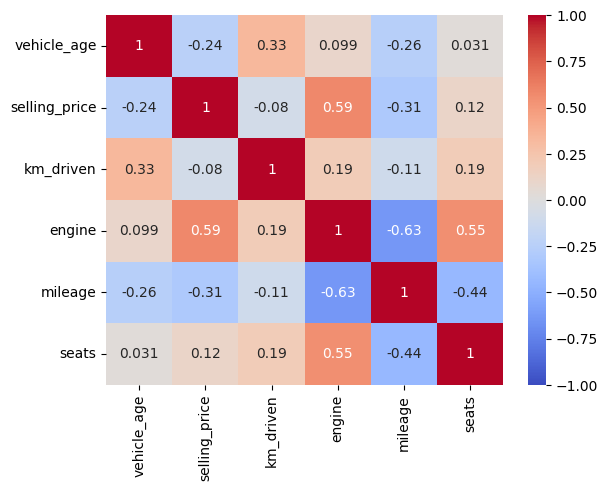

In [27]:
sns.heatmap(var,annot=True,vmin=-1,vmax=1,cmap='coolwarm')

In [28]:
x=df[['vehicle_age','km_driven','engine','mileage','seats']]
y=df['selling_price']

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
model=RandomForestRegressor(max_depth=10,n_estimators=100,random_state=42)

In [31]:
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [32]:
y_pred=model.predict(x_train)
r2=r2_score(y_train,y_pred)
print(f'r2_score(train): {r2:.4f}')

r2_score(train): 0.9387


In [33]:
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
print(f'r2_score(test):{r2:.4f}')

r2_score(test):0.9182
